# EcoScan PK - Advanced: High-Accuracy Material Classifier Training Notebook
This notebook demonstrates how to load a pre-trained **MobileNetV2** model and perform **two-stage fine-tuning** on the **MINC-2500 / Construction Materials** dataset. This method adapts the model specifically to texture recognition and achieves high classification accuracy.

### Two-Stage Fine-Tuning Strategy:
1. **Stage 1 (Warmup Classification Head):** Freeze MobileNetV2 base layers and train the newly added dense layers for 10 epochs. This prevents random initial gradients from destroying pre-trained weights.
2. **Stage 2 (Fine-Tuning Base Weights):** Unfreeze the base model layers and train the entire network with a **very small learning rate (1e-5)** for another 15 epochs to specialize the feature detectors for construction materials.

## 1. Setup Environment

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Prepare Large Dataset
We increase the limit to **1500 images per category** to give the model plenty of training samples.

In [2]:
CLASSES = ['Brick', 'Concrete', 'Glass', 'Steel', 'Wood', 'Marble', 'Granite', 'Tile', 'PVC', 'Paint']
DATASET_DIR = './dataset'

# Create directories for each class
for c in CLASSES:
    os.makedirs(os.path.join(DATASET_DIR, c), exist_ok=True)
print("Dataset directories initialized!")

Dataset directories initialized!


In [3]:
# Install HuggingFace datasets library
!pip install -q datasets

import os
from tqdm.notebook import tqdm
from datasets import load_dataset

print("📥 Downloading MINC-2500 split dataset from HuggingFace...")
ds = load_dataset("mcimpoi/minc-2500_split_1")

print("📂 Organizing images into category directories...")

# Increased limit to 1500 images per class for high-accuracy training
class_counts = {c: 0 for c in CLASSES}
limit_per_class = 1500

# Save images into local category folders for Keras training
for split in ['train', 'validation']:
    for idx, item in enumerate(tqdm(ds[split], desc=f"Processing {split} split")):
        label_idx = item['label']
        label_name = ds[split].features['label'].names[label_idx]

        # Map MINC labels to our folder structure
        folder_name = label_name.capitalize()
        if folder_name == 'Polishedstone': folder_name = 'Marble'
        if folder_name == 'Plastic': folder_name = 'PVC'
        if folder_name == 'Metal': folder_name = 'Steel'
        if folder_name == 'Painted': folder_name = 'Paint'

        # Only save if within target classes and class count limit
        if folder_name in CLASSES and class_counts[folder_name] < limit_per_class:
            save_dir = os.path.join(DATASET_DIR, folder_name)
            os.makedirs(save_dir, exist_ok=True)
            image_path = os.path.join(save_dir, f"{split}_{idx}.jpg")

            if not os.path.exists(image_path):
                item['image'].save(image_path)
                class_counts[folder_name] += 1

print("🎉 Dataset download and setup complete! Ready for training.")

📥 Downloading MINC-2500 split dataset from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005-dbe3fdb3f07f1f(…):   0%|          | 0.00/413M [00:00<?, ?B/s]

data/train-00001-of-00005-5b231f26456ca0(…):   0%|          | 0.00/442M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/5750 [00:00<?, ? examples/s]

📂 Organizing images into category directories...


Processing train split:   0%|          | 0/48875 [00:00<?, ?it/s]

Processing validation split:   0%|          | 0/2875 [00:00<?, ?it/s]

🎉 Dataset download and setup complete! Ready for training.


## 3. Image Preprocessing & Strong Data Augmentation

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Strong augmentation to prevent overfitting on texture databases
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15)
])

try:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    # Prefetch datasets for GPU speed
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
    print("Datasets loaded successfully!")
except Exception as e:
    print("Error loading dataset:", e)

Found 12000 files belonging to 10 classes.
Using 9600 files for training.
Found 12000 files belonging to 10 classes.
Using 2400 files for validation.
Datasets loaded successfully!


## 4. Build Model Structure (MobileNetV2)

In [5]:
base_model = applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
# Step 1: Lock the base model
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Training Phase 1: Classification Head Warmup (10 Epochs)

In [6]:
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 53s 69ms/step - accuracy: 0.4650 - loss: 1.5238 - val_accuracy: 0.5579 - val_loss: 1.2621
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 65ms/step - accuracy: 0.5335 - loss: 1.3340 - val_accuracy: 0.5629 - val_loss: 1.2426
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.5515 - loss: 1.2893 - val_accuracy: 0.5742 - val_loss: 1.2099
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.5607 - loss: 1.2451 - val_accuracy: 0.5863 - val_loss: 1.1837
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.5668 - loss: 1.2218 - val_accuracy: 0.5863 - val_loss: 1.1803
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.5632 - loss: 1.2234 - val_accuracy: 0.6004 - val_loss: 1.1496
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accuracy: 0.5723 - loss: 1.2016 - val_accuracy: 0.5967 - val_loss: 1.1574
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.5813 - loss: 1.1946 - 

## 6. Training Phase 2: Unfreeze & Deep Fine-Tuning (15 Epochs)
Here, we unfreeze the base layers and train the entire network with an extremely low learning rate (`1e-5`). This fine-tunes the MobileNet feature filters to classify construction textures.

In [7]:
# Unfreeze base model
base_model.trainable = True

# Recompile model with a very low learning rate (1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train again for 15 epochs
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 119s 265ms/step - accuracy: 0.4231 - loss: 1.7269 - val_accuracy: 0.5213 - val_loss: 1.5741
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 88s 263ms/step - accuracy: 0.5449 - loss: 1.2903 - val_accuracy: 0.5446 - val_loss: 1.4583
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 90s 269ms/step - accuracy: 0.5843 - loss: 1.1938 - val_accuracy: 0.5771 - val_loss: 1.3135
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 88s 267ms/step - accuracy: 0.6046 - loss: 1.1228 - val_accuracy: 0.6046 - val_loss: 1.2038
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 88s 266ms/step - accuracy: 0.6210 - loss: 1.0935 - val_accuracy: 0.6246 - val_loss: 1.1137
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 89s 266ms/step - accuracy: 0.6372 - loss: 1.0296 - val_accuracy: 0.6288 - val_loss: 1.0798
Epoch 7/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 89s 266ms/step - accuracy: 0.6485 - loss: 1.0122 - val_accuracy: 0.6562 - val_loss: 1.0026
Epoch 8/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 89s 266ms/step - accuracy: 0.6595 - loss: 

## 7. Plot Accuracy & Loss Curves

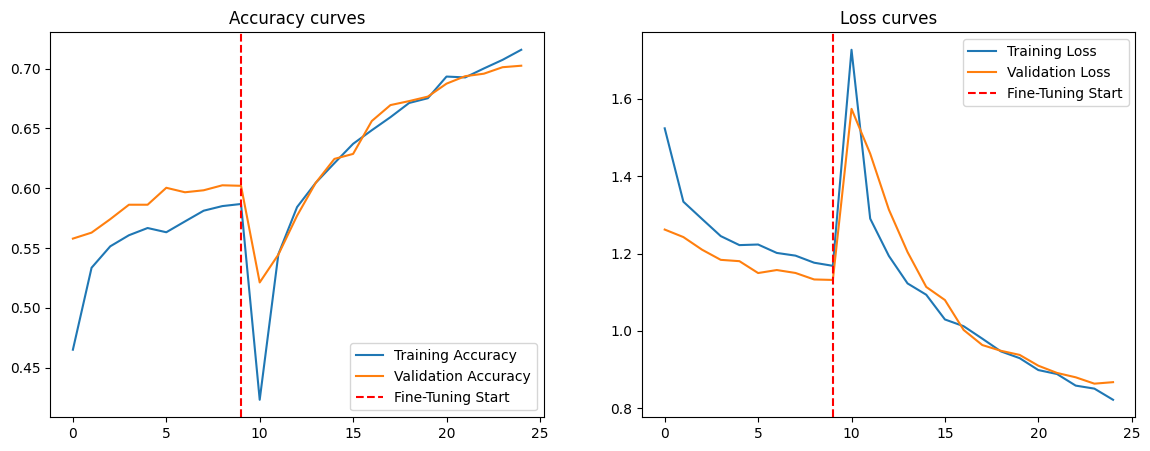

In [8]:
# Merge history stats
acc = history_warmup.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_warmup.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history_warmup.history['loss'] + history_finetune.history['loss']
val_loss = history_warmup.history['val_loss'] + history_finetune.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=9, color='r', linestyle='--', label='Fine-Tuning Start')
plt.legend(loc='lower right')
plt.title('Accuracy curves')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=9, color='r', linestyle='--', label='Fine-Tuning Start')
plt.legend(loc='upper right')
plt.title('Loss curves')
plt.show()

## 8. Export Optimized Weights

In [9]:
try:
    model.save('material_classifier.h5')
    print("✅ Saved high-accuracy weights file 'material_classifier.h5'!")
    from google.colab import files
    files.download('material_classifier.h5')
except Exception as e:
    print("Error exporting model:", e)

✅ Saved high-accuracy weights file 'material_classifier.h5'!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>